In [1]:
!pip install roboflow torch torchvision pillow matplotlib opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 40.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 117.2 MB/s eta 0:00:0000:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.26.0 requires google-cloud-bigquery-st

In [2]:
import os
import random
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import cv2

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

# Object detection Train data

In [7]:
from roboflow import Roboflow
rf = Roboflow(api_key="HTIPiNUJmtEs91eu6hVh")
project = rf.workspace("rhythms-workspace").project("fruitsv2-duplk-jz5tp")
version = project.version(1)
dataset = version.download("yolov5")      

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Fruitsv2-1 in yolov5pytorch:: 100%|██████████| 8356/8356 [00:00<00:00, 12661.29it/s]


# Test data

In [8]:
from roboflow import Roboflow
rf = Roboflow(api_key="HTIPiNUJmtEs91eu6hVh")
project = rf.workspace("rhythms-workspace").project("fruitsv2-duplk-jz5tp")
version = project.version(2)
dataset = version.download("yolov5")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Fruitsv2-2 in yolov5pytorch:: 100%|██████████| 3220/3220 [00:00<00:00, 7778.77it/s]


In [9]:
DATASET_PATH_TRAIN = "/kaggle/working/Fruitsv2-1"
DATASET_PATH_TEST = "/kaggle/working/Fruitsv2-2"

train_images = os.path.join(DATASET_PATH_TRAIN, "train/images")
train_labels = os.path.join(DATASET_PATH_TRAIN, "train/labels")

valid_images = os.path.join(DATASET_PATH_TEST, "valid/images")
valid_labels = os.path.join(DATASET_PATH_TEST, "valid/labels")

test_images = os.path.join(DATASET_PATH_TEST, "test/images")
test_labels = os.path.join(DATASET_PATH_TEST, "test/labels")

In [10]:
print("Train images:", len(os.listdir(train_images)))
print("Valid images:", len(os.listdir(valid_images)))
print("Test images:", len(os.listdir(test_images)))

Train images: 3852
Valid images: 160
Test images: 160


# Images and labels check

In [11]:
import os
import random
import cv2
import matplotlib.pyplot as plt

def yolo_to_bbox(label_path, img_w, img_h):
    boxes = []
    with open(label_path) as f:
        for line in f:
            cls, x, y, w, h = map(float, line.split())
            x1 = int((x - w/2) * img_w)
            y1 = int((y - h/2) * img_h)
            x2 = int((x + w/2) * img_w)
            y2 = int((y + h/2) * img_h)
            boxes.append((x1, y1, x2, y2))
    return boxes
def show_random_bbox(image_dir, label_dir):
    img_name = random.choice(os.listdir(image_dir))
    
    img_path = os.path.join(image_dir, img_name)
    label_path = os.path.join(label_dir, img_name.replace(".jpg", ".txt"))
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    
    boxes = yolo_to_bbox(label_path, w, h)
    
    for (x1, y1, x2, y2) in boxes:
        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)
    
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()


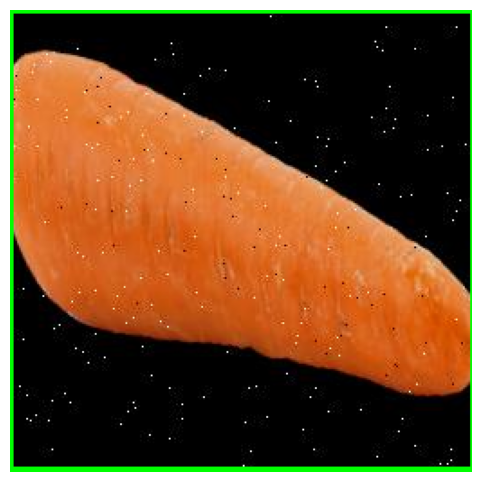

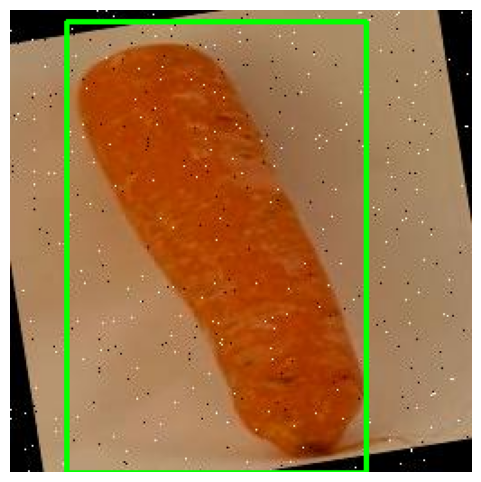

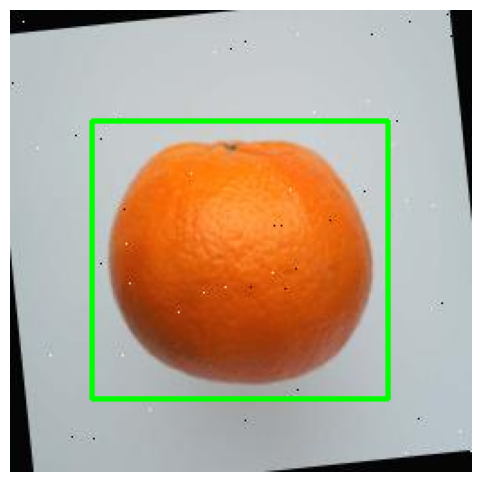

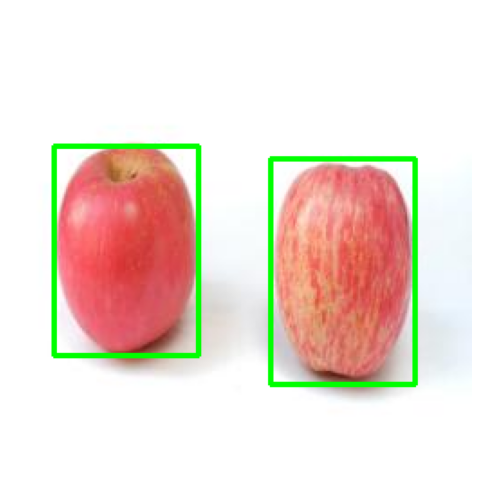

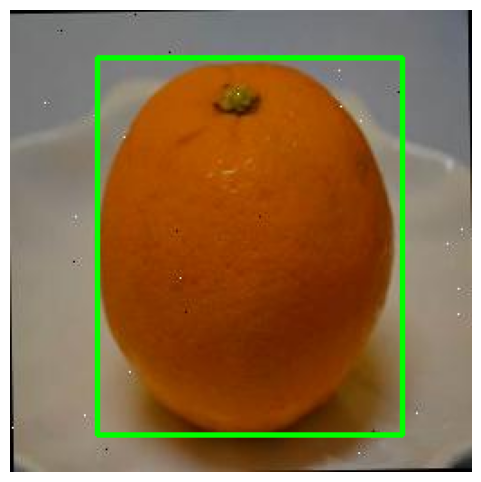

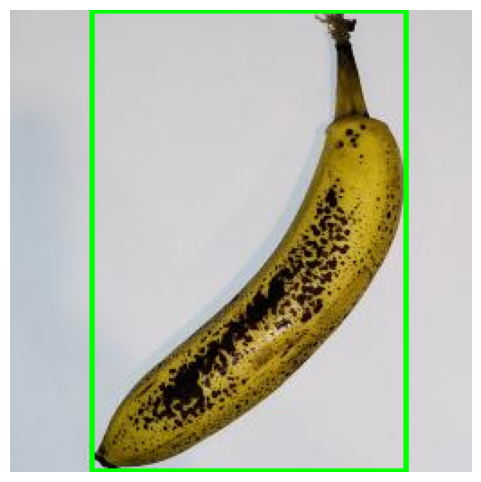

In [12]:
for _ in range(6):
    show_random_bbox(train_images, train_labels)

# Custom DataSet and Model

In [13]:
import torch
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Updated transform to use your 128x128 preference
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

def build_target_tensor(label_path, grid_size=8, num_classes=1):
    target = torch.zeros((grid_size, grid_size, 5 + num_classes))
    
    if not os.path.exists(label_path):
        return target

    with open(label_path, 'r') as f:
        for line in f:
            data = line.split()
            if not data: continue
            
            cls = int(data[0])
            x, y, w, h = map(float, data[1:])

            # Safety 1: Use min() to prevent index 8 on a size 8 grid
            i = min(int(y * grid_size), grid_size - 1)
            j = min(int(x * grid_size), grid_size - 1)

            x_cell = x * grid_size - j
            y_cell = y * grid_size - i

            if target[i, j, 4] == 0: 
                target[i, j, 4] = 1.0  # Confidence (Object exists)
                target[i, j, 0] = x_cell
                target[i, j, 1] = y_cell
                target[i, j, 2] = w
                target[i, j, 3] = h
                
                # Safety 2: Ensure we don't exceed the number of classes defined
                if cls < num_classes:
                    target[i, j, 5 + cls] = 1.0
    return target

class FruitDetectionDataset(Dataset):
    def __init__(self, img_dir, label_dir, transform=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.images = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]
        self.transform = transform
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        label_path = os.path.join(self.label_dir, self.images[idx].replace(".jpg", ".txt"))
        
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
            
        target = build_target_tensor(label_path)
        return img, target

In [14]:
from torch.utils.data import DataLoader

train_ds = FruitDetectionDataset(train_images, train_labels, transform = transform)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)

In [15]:
images, targets = next(iter(train_loader))

print("Images:", images.shape)
print("Targets:", targets.shape)
print("First target:", targets[0])


Images: torch.Size([16, 3, 128, 128])
Targets: torch.Size([16, 8, 8, 6])
First target: tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]],

        [[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.9219, 0.9062, 0.2656, 0.3398, 1.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_tensor_with_grid_boxes(img_tensor, grid_tensor, conf_thresh=0.5):
    """
    img_tensor: [3,128,128]
    grid_tensor: [8,8,6]  (x_cell, y_cell, w, h, conf, class)
    """
    img = img_tensor.permute(1,2,0).numpy()
    img = (img * 255).astype(np.uint8).copy()
    
    H, W, _ = img.shape
    grid_size = grid_tensor.shape[0]
    cell_size = W // grid_size
    
    for i in range(grid_size):
        for j in range(grid_size):
            cell = grid_tensor[i, j]
            conf = cell[4].item()
            
            if conf < conf_thresh:
                continue
            
            x_cell, y_cell, w, h = cell[:4]
            
            # Convert from cell-relative → image-relative
            x_center = (j + x_cell) * cell_size
            y_center = (i + y_cell) * cell_size
            
            box_w = w * W
            box_h = h * H
            
            x1 = int(x_center - box_w / 2)
            y1 = int(y_center - box_h / 2)
            x2 = int(x_center + box_w / 2)
            y2 = int(y_center + box_h / 2)
            
            cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)
    
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.show()


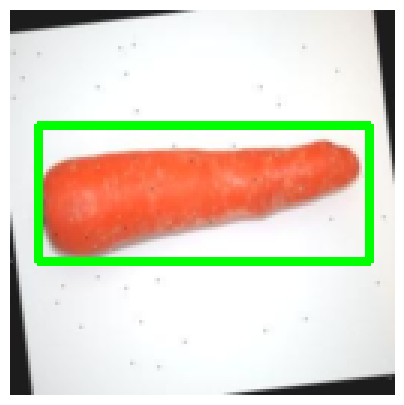

In [17]:
show_tensor_with_grid_boxes(images[10], targets[10], conf_thresh=0.5)


In [18]:
import torch.nn as nn

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ---------- Basic Conv Block ----------

class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU()
        )

    def forward(self, x):
        return self.conv(x)


# ---------- Backbone ----------

class Backbone(nn.Module):
    def __init__(self):
        super().__init__()

        self.stage1 = ConvBlock(3, 32)
        self.stage2 = ConvBlock(32, 64)
        self.stage3 = ConvBlock(64, 128)
        self.stage4 = ConvBlock(128, 256)
        self.stage5 = ConvBlock(256, 512)

        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        x = self.stage1(x)
        x = self.pool(x)     # 64x64

        x = self.stage2(x)
        x = self.pool(x)     # 32x32
        f_small = x          # for small objects

        x = self.stage3(x)
        x = self.pool(x)     # 16x16
        f_medium = x

        x = self.stage4(x)
        x = self.pool(x)     # 8x8

        x = self.stage5(x)
        f_large = x

        return f_small, f_medium, f_large


# ---------- YOLO Head ----------

class YOLOHead(nn.Module):
    def __init__(self, in_c, num_classes, num_anchors=3):
        super().__init__()
        self.pred = nn.Conv2d(
            in_c,
            num_anchors * (5 + num_classes),
            kernel_size=1
        )

    def forward(self, x):
        x = self.pred(x)
        B, C, H, W = x.shape
        x = x.permute(0, 2, 3, 1)   # B,H,W,C
        return torch.sigmoid(x)


# ---------- Full Model ----------

class TinyYOLO(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.backbone = Backbone()

        self.head_small = YOLOHead(64, num_classes)
        self.head_medium = YOLOHead(128, num_classes)
        self.head_large = YOLOHead(512, num_classes)

    def forward(self, x):
        f_small, f_medium, f_large = self.backbone(x)

        out_small = self.head_small(f_small)     # 32x32
        out_medium = self.head_medium(f_medium)  # 16x16
        out_large = self.head_large(f_large)     # 8x8

        return out_small, out_medium, out_large


In [21]:
def bbox_iou(box1, box2, eps=1e-7):
    # box format: x, y, w, h (relative)

    b1_x1 = box1[..., 0] - box1[..., 2] / 2
    b1_y1 = box1[..., 1] - box1[..., 3] / 2
    b1_x2 = box1[..., 0] + box1[..., 2] / 2
    b1_y2 = box1[..., 1] + box1[..., 3] / 2

    b2_x1 = box2[..., 0] - box2[..., 2] / 2
    b2_y1 = box2[..., 1] - box2[..., 3] / 2
    b2_x2 = box2[..., 0] + box2[..., 2] / 2
    b2_y2 = box2[..., 1] + box2[..., 3] / 2

    inter_x1 = torch.max(b1_x1, b2_x1)
    inter_y1 = torch.max(b1_y1, b2_y1)
    inter_x2 = torch.min(b1_x2, b2_x2)
    inter_y2 = torch.min(b1_y2, b2_y2)

    inter_area = (inter_x2 - inter_x1).clamp(0) * (inter_y2 - inter_y1).clamp(0)

    area1 = (b1_x2 - b1_x1) * (b1_y2 - b1_y1)
    area2 = (b2_x2 - b2_x1) * (b2_y2 - b2_y1)

    union = area1 + area2 - inter_area + eps

    return inter_area / union


def yolo_iou_loss(pred, target):
    obj_mask = target[..., 4] == 1
    noobj_mask = target[..., 4] == 0

    pred_box = pred[..., :4]
    target_box = target[..., :4]

    iou = bbox_iou(pred_box[obj_mask], target_box[obj_mask])
    box_loss = 1 - iou.mean()

    obj_conf_loss = F.binary_cross_entropy(
        pred[obj_mask][..., 4], 
        target[obj_mask][..., 4]
    )

    noobj_conf_loss = F.binary_cross_entropy(
        pred[noobj_mask][..., 4], 
        target[noobj_mask][..., 4]
    )

    return box_loss + obj_conf_loss + 0.5 * noobj_conf_loss


In [23]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = TinyYOLO(num_classes=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
device

'cuda'

In [24]:
model

TinyYOLO(
  (backbone): Backbone(
    (stage1): ConvBlock(
      (conv): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU()
      )
    )
    (stage2): ConvBlock(
      (conv): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU()
      )
    )
    (stage3): ConvBlock(
      (conv): Sequential(
        (0): Conv2

In [25]:
import torch
import torch.nn.functional as F
num_epochs = 100 
loss_history = []

for epoch in range(num_epochs):
    epoch_num = epoch + 1
    model.train()
    running_loss = 0
    
    for i, (imgs, targets) in enumerate(train_loader):
        imgs, targets = imgs.to(device), targets.to(device)
        
        # Forward pass
        preds_small, preds_medium, preds_large = model(imgs)
        loss = yolo_iou_loss(preds_large, targets)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    avg_loss = running_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch [{epoch_num}/{num_epochs}] - Loss: {avg_loss:.4f}")

    #checkpoint saving
    checkpoint = {
        'epoch': epoch_num,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss_history': loss_history
    }
    torch.save(checkpoint, "model_latest.pth")

    if epoch_num % 5 == 0:
        checkpoint_name = f"model_epoch_{epoch_num}.pth"
        torch.save(checkpoint, checkpoint_name)
        print(f"-------> Periodic Checkpoint Saved: {checkpoint_name}")

print("Training finished")

Epoch [1/100] - Loss: 1.1495
Epoch [2/100] - Loss: 0.9351
Epoch [3/100] - Loss: 0.8249
Epoch [4/100] - Loss: 0.7614
Epoch [5/100] - Loss: 0.7101
-------> Periodic Checkpoint Saved: model_epoch_5.pth
Epoch [6/100] - Loss: 0.6715
Epoch [7/100] - Loss: 0.6404
Epoch [8/100] - Loss: 0.6114
Epoch [9/100] - Loss: 0.5960
Epoch [10/100] - Loss: 0.5698
-------> Periodic Checkpoint Saved: model_epoch_10.pth
Epoch [11/100] - Loss: 0.5509
Epoch [12/100] - Loss: 0.5323
Epoch [13/100] - Loss: 0.5118
Epoch [14/100] - Loss: 0.5008
Epoch [15/100] - Loss: 0.4785
-------> Periodic Checkpoint Saved: model_epoch_15.pth
Epoch [16/100] - Loss: 0.4653
Epoch [17/100] - Loss: 0.4519
Epoch [18/100] - Loss: 0.4446
Epoch [19/100] - Loss: 0.4350
Epoch [20/100] - Loss: 0.4157
-------> Periodic Checkpoint Saved: model_epoch_20.pth
Epoch [21/100] - Loss: 0.4034
Epoch [22/100] - Loss: 0.3892
Epoch [23/100] - Loss: 0.3791
Epoch [24/100] - Loss: 0.3716
Epoch [25/100] - Loss: 0.3657
-------> Periodic Checkpoint Saved: mode

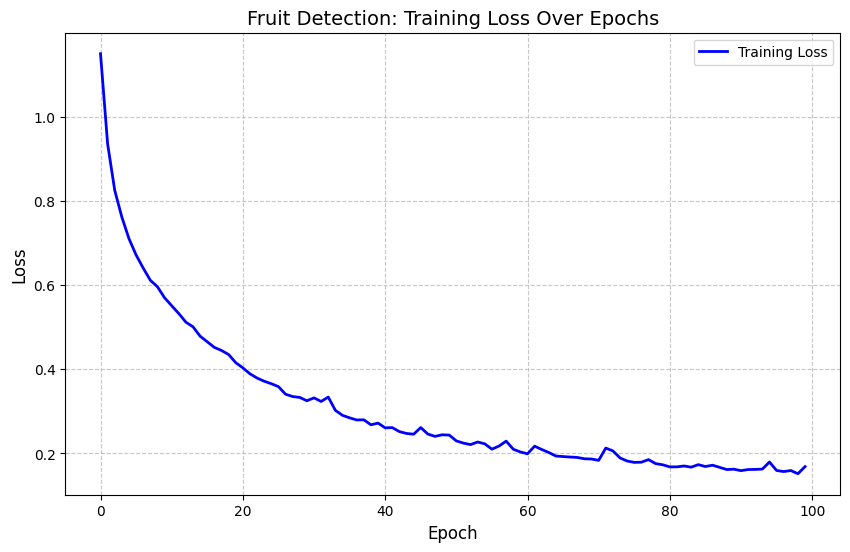

In [26]:
import matplotlib.pyplot as plt

def plot_loss(loss_history):
    plt.figure(figsize=(10, 6))
    plt.plot(loss_history, label='Training Loss', color='blue', linewidth=2)
    plt.title('Fruit Detection: Training Loss Over Epochs', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()


plot_loss(loss_history)

NMS is a filtering step that looks at all these overlapping boxes and says: "If two boxes overlap a lot and are looking for the same thing, keep the one with the highest confidence and delete the other."

# Testing

In [27]:
# test dataloader
test_ds = FruitDetectionDataset(test_images,test_labels,transform=transform)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

In [28]:
def calculate_iou(box1, box2):
    # box format: [x1, y1, x2, y2]
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    if x_right < x_left or y_bottom < y_top:
        return 0.0

    intersection_area = (x_right - x_left) * (y_bottom - y_top)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    
    iou = intersection_area / float(area1 + area2 - intersection_area)
    return iou

In [29]:
from torchvision.ops import nms

def run_test_with_accuracy(model, loader, device, conf_thresh=0.5, iou_thresh=0.3):
    model.eval()
    total_test_loss = 0
    correct_detections = 0
    total_ground_truth_objects = 0

    with torch.inference_mode():
        for imgs, targets in loader:
            imgs, targets = imgs.to(device), targets.to(device)

            # Get only large-scale output (8x8)
            _, _, preds_large = model(imgs)

            total_test_loss += yolo_iou_loss(preds_large, targets).item()

            # Process each image
            for b in range(preds_large.shape[0]):
                single_pred = preds_large[b].cpu()
                single_target = targets[b].cpu()

                # ---- Predicted boxes ----
                pred_boxes = []
                scores = []

                for r in range(8):
                    for c in range(8):
                        if single_pred[r, c, 4] > conf_thresh:
                            xc, yc, w, h = single_pred[r, c, 0:4]

                            x1 = ((c + xc)/8 - w/2) * 128
                            y1 = ((r + yc)/8 - h/2) * 128
                            x2 = ((c + xc)/8 + w/2) * 128
                            y2 = ((r + yc)/8 + h/2) * 128

                            pred_boxes.append([x1, y1, x2, y2])
                            scores.append(single_pred[r, c, 4].item())

                if pred_boxes:
                    keep_idx = nms(
                        torch.tensor(pred_boxes),
                        torch.tensor(scores),
                        iou_thresh
                    )
                    final_preds = [pred_boxes[i] for i in keep_idx]
                else:
                    final_preds = []

                # ---- Ground truth boxes ----
                gt_boxes = []

                for r in range(8):
                    for c in range(8):
                        if single_target[r, c, 4] == 1:
                            txc, tyc, tw, th = single_target[r, c, 0:4]

                            tx1 = ((c + txc)/8 - tw/2) * 128
                            ty1 = ((r + tyc)/8 - th/2) * 128
                            tx2 = ((c + txc)/8 + tw/2) * 128
                            ty2 = ((r + tyc)/8 + th/2) * 128

                            gt_boxes.append([tx1, ty1, tx2, ty2])

                total_ground_truth_objects += len(gt_boxes)

                # ---- IoU matching (recall-style accuracy) ----
                for gt in gt_boxes:
                    for pr in final_preds:
                        if calculate_iou(gt, pr) > 0.5:
                            correct_detections += 1
                            break

    accuracy = (correct_detections / total_ground_truth_objects) * 100 if total_ground_truth_objects > 0 else 0

    print(f"Test Loss: {total_test_loss/len(loader):.4f}")
    print(f"Object Detection Accuracy (Recall): {accuracy:.2f}%")

    return accuracy


acc = run_test_with_accuracy(model, test_loader, device)

Test Loss: 4.0388
Object Detection Accuracy (Recall): 82.23%


# Object Detection model done

# testing same model on FruitVision

In [30]:
def grid_to_boxes(grid, conf_thresh=0.3):
    boxes = []
    S = grid.shape[0]

    for i in range(S):
        for j in range(S):
            cell = grid[i, j]
            conf = cell[4].item()

            if conf < conf_thresh:
                continue

            x_cell, y_cell, w, h = cell[:4]

            x_center = (j + x_cell) / S
            y_center = (i + y_cell) / S

            x1 = max(0, x_center - w / 2)
            y1 = max(0, y_center - h / 2)
            x2 = min(1, x_center + w / 2)
            y2 = min(1, y_center + h / 2)

            boxes.append([x1, y1, x2, y2])

    return boxes


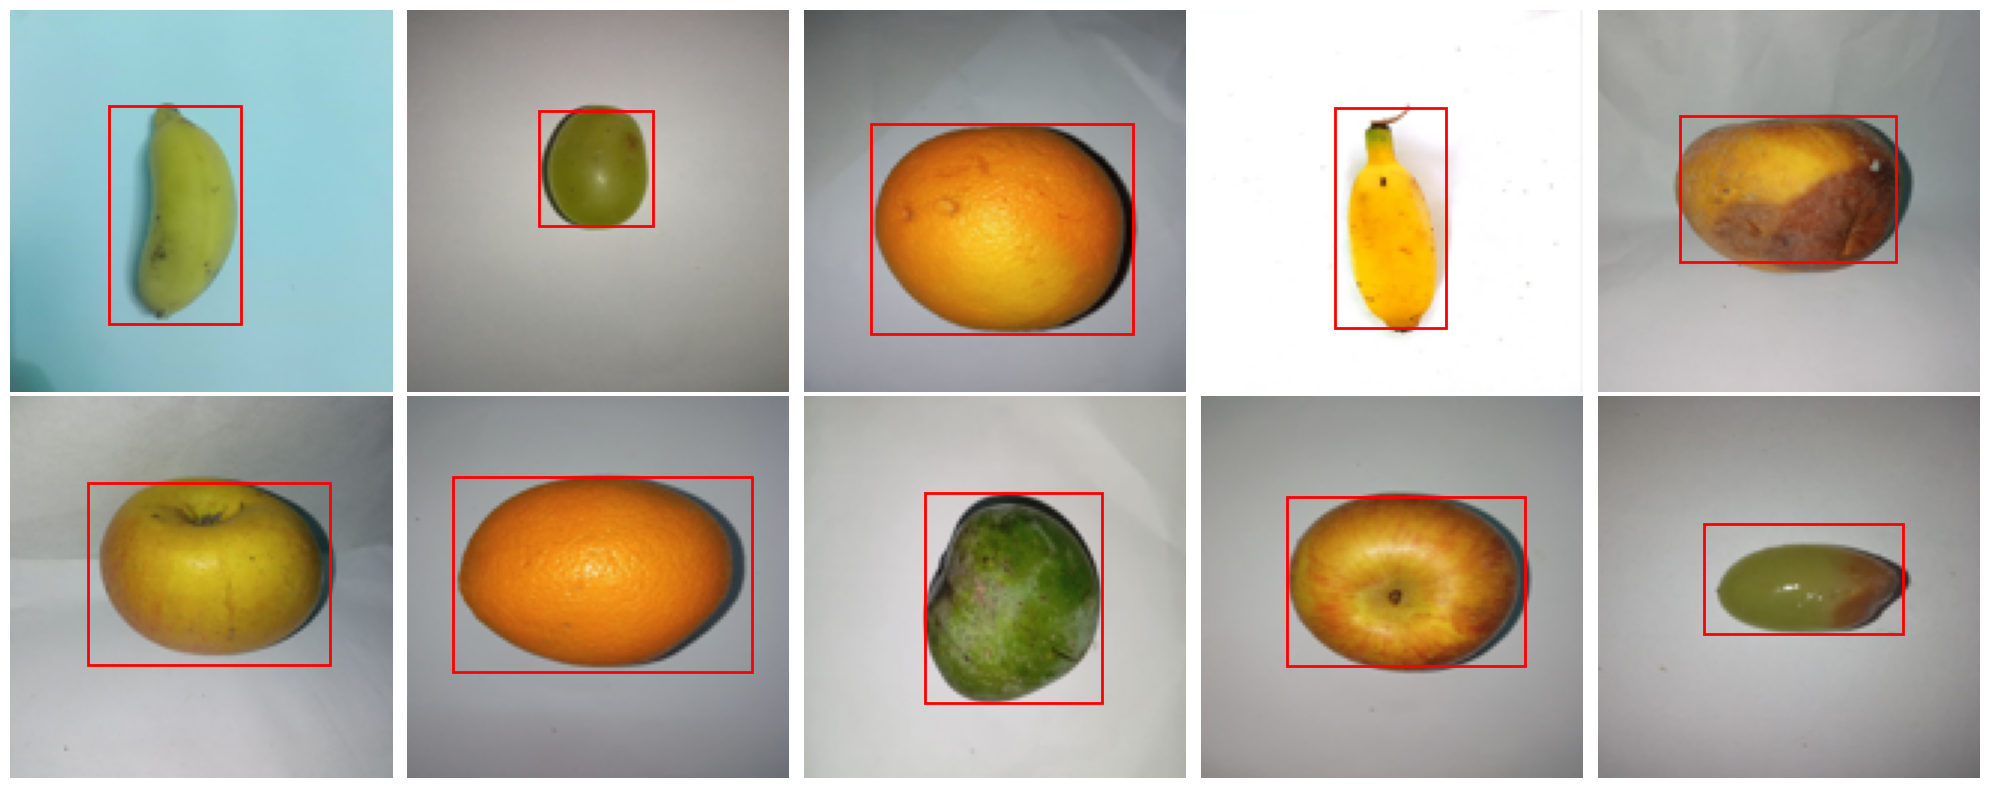

In [32]:
import random
import glob
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch
from torchvision.ops import nms
from torchvision import transforms

# -------- Config --------

BASE_DIR = "/kaggle/input/fruitnet-formalin-rotten-fresh-multiclassv1/FruitVision A Benchmark Dataset for Fresh, Rotten, and Formalin-mixed Fruit Detection"

IMG_SIZE = 128

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

# -------- Collect random images --------

def collect_images():
    paths = []
    fruits = ["Apple", "Banana", "Grape", "Mango", "Orange"]

    for fruit in fruits:
        pattern = f"{BASE_DIR}/Fruits Original/{fruit}/**/*.jpg"
        paths.extend(glob.glob(pattern, recursive=True))

    return paths



all_images = collect_images()
random_imgs = random.sample(all_images, 10)

# -------- Visualization --------

model.eval()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for ax, img_path in zip(axes.flatten(), random_imgs):

    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.inference_mode():
        _, _, preds_large = model(img_tensor)

    grid = preds_large[0].cpu()

    boxes = grid_to_boxes(grid, conf_thresh=0.4)

    # Apply NMS
    if boxes:
        boxes_tensor = torch.tensor(boxes)
        scores = []

        for b in boxes:
            scores.append(1.0)   # simple since we filtered by conf already

        keep = nms(boxes_tensor, torch.tensor(scores), 0.3)
        boxes = [boxes[i] for i in keep]

    # Plot
    ax.imshow(img.resize((IMG_SIZE, IMG_SIZE)))
    ax.axis("off")

    for x1, y1, x2, y2 in boxes:
        rect = patches.Rectangle(
            (x1 * IMG_SIZE, y1 * IMG_SIZE),
            (x2 - x1) * IMG_SIZE,
            (y2 - y1) * IMG_SIZE,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(rect)

plt.tight_layout()
plt.show()


# Making another dataset using same model to get cropped images for embedding


In [33]:
import os
import cv2
import torch
from torchvision.ops import nms
from tqdm import tqdm


SAVE_DIR = "/kaggle/working/fruit_crops"
os.makedirs(SAVE_DIR, exist_ok=True)

BASE_DIR = "/kaggle/input/fruitnet-formalin-rotten-fresh-multiclassv1/FruitVision A Benchmark Dataset for Fresh, Rotten, and Formalin-mixed Fruit Detection"


# -------- Crop function --------

def crop_fruits_from_folder(img_dir, save_dir, prefix, conf_thresh=0.4, iou_thresh=0.4):
    
    files = os.listdir(img_dir)
    count = 0

    for name in tqdm(files, desc=prefix):

        if not name.lower().endswith(".jpg"):
            continue

        path = os.path.join(img_dir, name)

        img = cv2.imread(path)
        if img is None:
            continue

        H, W, _ = img.shape

        # YOLO input
        img_resized = cv2.resize(img, (128,128))
        x = torch.tensor(img_resized).permute(2,0,1).unsqueeze(0).float() / 255.0
        x = x.to(device)

        with torch.no_grad():
            _, _, preds_large = model(x)

        pred = preds_large[0].cpu()

        boxes = []
        scores = []

        for r in range(8):
            for c in range(8):
                if pred[r, c, 4] > conf_thresh:

                    xc, yc, w, h = pred[r, c, 0:4]

                    x1 = ((c + xc)/8 - w/2) * W
                    y1 = ((r + yc)/8 - h/2) * H
                    x2 = ((c + xc)/8 + w/2) * W
                    y2 = ((r + yc)/8 + h/2) * H

                    boxes.append([x1, y1, x2, y2])
                    scores.append(pred[r, c, 4].item())

        if boxes:
            keep = nms(torch.tensor(boxes), torch.tensor(scores), iou_thresh)
            boxes = [boxes[i] for i in keep]
        else:
            boxes = []

        # Save all crops
        for (x1, y1, x2, y2) in boxes:

            x1, y1 = max(0,int(x1)), max(0,int(y1))
            x2, y2 = min(W,int(x2)), min(H,int(y2))

            crop = img[y1:y2, x1:x2]

            if crop.size == 0:
                continue

            save_path = os.path.join(save_dir, f"{prefix}_{count:06d}.jpg")
            cv2.imwrite(save_path, crop)
            count += 1

    print(f"{prefix} → saved {count} crops")


# -------- Walk through ALL FruitVision folders --------

def process_all_fruitvision():

    total = 0

    # Main fruit folders (augmented)
    fruits = ["Apple", "Banana", "Grape", "Mango", "Orange"]
    classes = ["Fresh", "Rotten", "Formalin-mixed"]

    for fruit in fruits:
        for cls in classes:

            folder = f"{BASE_DIR}/{fruit}/{cls}/{cls}"

            if os.path.exists(folder):
                crop_fruits_from_folder(
                    folder,
                    SAVE_DIR,
                    prefix=f"{fruit}_{cls}"
                )

    # Original images
    for fruit in fruits:

        orig_folder = f"{BASE_DIR}/Fruits Original/{fruit}"

        if os.path.exists(orig_folder):
            crop_fruits_from_folder(
                orig_folder,
                SAVE_DIR,
                prefix=f"{fruit}_original"
            )


process_all_fruitvision()

print("Cropping finished")

Apple_Fresh: 100%|██████████| 6120/6120 [01:18<00:00, 78.35it/s]


Apple_Fresh → saved 3224 crops


Apple_Rotten: 100%|██████████| 377/377 [00:04<00:00, 77.84it/s]


Apple_Rotten → saved 168 crops


Apple_Formalin-mixed: 100%|██████████| 1964/1964 [00:25<00:00, 77.27it/s]


...

Grape_original → saved 0 crops


Mango_original: 100%|██████████| 4/4 [00:00<00:00, 42048.16it/s]


Mango_original → saved 0 crops


Orange_original: 100%|██████████| 4/4 [00:00<00:00, 62368.83it/s]

Orange_original → saved 0 crops
Cropping finished


In [34]:
import os
import cv2
import torch
from torchvision.ops import nms

BASE_DIR = "/kaggle/input/fruitnet-formalin-rotten-fresh-multiclassv1/FruitVision A Benchmark Dataset for Fresh, Rotten, and Formalin-mixed Fruit Detection"
SAVE_DIR = "/kaggle/working/fruit_crops"

fruits = ["Apple", "Banana", "Grape", "Mango", "Orange"]
classes = ["Fresh", "Rotten", "Formalin-mixed"]


def crop_original_only():

    for fruit in fruits:
        for cls in classes:

            folder = f"{BASE_DIR}/Fruits Original/{fruit}/{cls}"

            if not os.path.exists(folder):
                continue

            files = os.listdir(folder)
            count = 0

            for name in tqdm(files, desc=f"{fruit}_{cls}_original"):

                if not name.lower().endswith(".jpg"):
                    continue

                path = os.path.join(folder, name)

                img = cv2.imread(path)
                if img is None:
                    continue

                H, W, _ = img.shape

                img_resized = cv2.resize(img, (128,128))
                x = torch.tensor(img_resized).permute(2,0,1).unsqueeze(0).float()/255.0
                x = x.to(device)

                with torch.no_grad():
                    _, _, preds_large = model(x)

                pred = preds_large[0].cpu()

                boxes = []
                scores = []

                for r in range(8):
                    for c in range(8):
                        if pred[r,c,4] > 0.4:

                            xc, yc, w, h = pred[r,c,0:4]

                            x1 = ((c + xc)/8 - w/2) * W
                            y1 = ((r + yc)/8 - h/2) * H
                            x2 = ((c + xc)/8 + w/2) * W
                            y2 = ((r + yc)/8 + h/2) * H

                            boxes.append([x1,y1,x2,y2])
                            scores.append(pred[r,c,4].item())

                if boxes:
                    keep = nms(torch.tensor(boxes), torch.tensor(scores), 0.4)
                    boxes = [boxes[i] for i in keep]
                else:
                    boxes = []

                for (x1,y1,x2,y2) in boxes:

                    x1, y1 = max(0,int(x1)), max(0,int(y1))
                    x2, y2 = min(W,int(x2)), min(H,int(y2))

                    crop = img[y1:y2, x1:x2]

                    if crop.size == 0:
                        continue

                    save_path = os.path.join(
                        SAVE_DIR,
                        f"{fruit}_{cls}_original_{count:06d}.jpg"
                    )

                    cv2.imwrite(save_path, crop)
                    count += 1

            print(f"{fruit}_{cls}_original → saved {count} crops")


crop_original_only()

Apple_Fresh_original: 100%|██████████| 766/766 [00:15<00:00, 48.76it/s]


Apple_Fresh_original → saved 338 crops


Apple_Rotten_original: 100%|██████████| 631/631 [00:13<00:00, 46.22it/s]


Apple_Rotten_original → saved 233 crops


Apple_Formalin-mixed_original: 100%|██████████| 644/644 [00:13<00:00, 46.20it/s]


...

Orange_Fresh_original → saved 196 crops


Orange_Rotten_original: 100%|██████████| 656/656 [00:15<00:00, 41.51it/s]


Orange_Rotten_original → saved 356 crops


Orange_Formalin-mixed_original: 100%|██████████| 647/647 [00:14<00:00, 44.94it/s]

Orange_Formalin-mixed_original → saved 279 crops


In [35]:
len(os.listdir("/kaggle/working/fruit_crops"))

45330

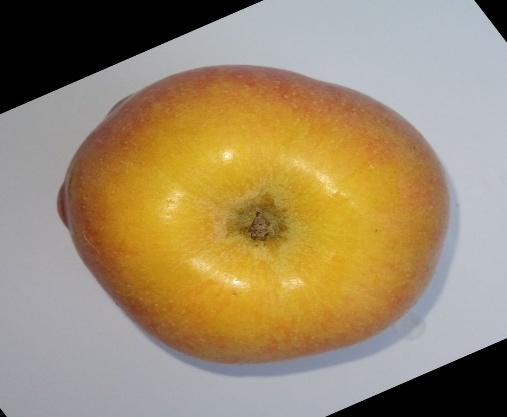

In [46]:
import random
from PIL import Image
import matplotlib.pyplot as plt

img = random.choice(os.listdir("/kaggle/working/fruit_crops"))
display(Image.open("/kaggle/working/fruit_crops/"+img))

# Embedding using SimCLR

In [49]:
import os
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

simclr_transform = transforms.Compose([
    transforms.RandomResizedCrop(128, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
    transforms.RandomGrayscale(p=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor()
])

class FruitSimCLRDataset(Dataset):
    def __init__(self, root):
        self.files = [os.path.join(root,f) for f in os.listdir(root)]
        
    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")
        return simclr_transform(img), simclr_transform(img)

print("ok")

ok


## Encoder CNN

In [50]:
import torch.nn as nn
import torch.nn.functional as F

class FruitEncoder(nn.Module):
    def __init__(self, emb_dim=256):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        
        self.fc = nn.Linear(256, emb_dim)
        
    def forward(self, x):
        x = self.net(x).flatten(1)
        return self.fc(x)
print("ok")

ok


In [51]:
class ProjectionHead(nn.Module):
    def __init__(self, emb_dim=256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128)
        )
    
    def forward(self, x):
        return self.mlp(x)
print("ok")

ok


### Contrastive Loss (NT-Xent)

In [52]:
import torch.nn.functional as F

def simclr_loss(z1, z2, temp=0.5):

    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    
    B = z1.size(0)
    z = torch.cat([z1, z2], dim=0)   # [2B, D]

    # --- force FP32 for similarity ---
    with torch.cuda.amp.autocast(enabled=False):
        z = z.float()
        sim = torch.matmul(z, z.T) / temp

        mask = torch.eye(2*B, device=z.device).bool()
        sim.masked_fill_(mask, -1e9)

        targets = torch.arange(B, device=z.device)
        targets = torch.cat([targets + B, targets], dim=0)

        loss = F.cross_entropy(sim, targets)

    return loss
print("ok")


ok


### Training encoder

In [39]:
from torch.utils.data import DataLoader

dataset = FruitSimCLRDataset("/kaggle/working/fruit_crops")
loader = DataLoader(dataset, batch_size=6, shuffle=True, drop_last=True,num_workers=2)

encoder = FruitEncoder().to(device)
projector = ProjectionHead().to(device)

opt = torch.optim.Adam(list(encoder.parameters()) + list(projector.parameters()), lr=3e-4)

In [40]:
device

'cuda'

In [ ]:
from torch.amp import autocast, GradScaler

scaler = GradScaler("cuda")
num_epochs = 30
loss_history = []

for epoch in range(num_epochs):
    encoder.train()
    projector.train()
    total_loss = 0
    
    for i, (x1, x2) in enumerate(tqdm(loader, desc=f"Epoch {epoch+1}/{num_epochs}")):

        x1, x2 = x1.to(device), x2.to(device)
        
        with autocast("cuda"):
            z1 = projector(encoder(x1))
            z2 = projector(encoder(x2))
            loss = simclr_loss(z1, z2)

        
        opt.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        
        total_loss += loss.item()
        
        if i % 20 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | Batch {i}/{len(loader)} | Loss {loss.item():.3f}")
    
    avg_loss = total_loss / len(loader)
    loss_history.append(avg_loss)
    
    print(f"Epoch {epoch+1} completed | Avg SimCLR loss: {avg_loss:.3f}")
    
    torch.save({
        "epoch": epoch+1,
        "encoder": encoder.state_dict(),
        "projector": projector.state_dict(),
        "optimizer": opt.state_dict(),
        "loss_history": loss_history
    }, "/kaggle/working/simclr_latest.pth")
    
    if (epoch+1) % 10 == 0:
        torch.save({
            "epoch": epoch+1,
            "encoder": encoder.state_dict(),
            "projector": projector.state_dict(),
            "optimizer": opt.state_dict(),
            "loss_history": loss_history
        }, f"/kaggle/working/simclr_epoch_{epoch+1}.pth")


Epoch 1/30:   1%|          | 2/354 [00:02<05:18,  1.10it/s]

Epoch 1/30 | Batch 0/354 | Loss 5.541


Epoch 1/30:   6%|▌         | 21/354 [00:15<03:53,  1.42it/s]

Epoch 1/30 | Batch 20/354 | Loss 5.378


Epoch 1/30:  12%|█▏        | 41/354 [00:29<03:05,  1.69it/s]

...

Epoch 16/30:  40%|███▉      | 141/354 [01:38<02:24,  1.48it/s]

Epoch 16/30 | Batch 140/354 | Loss 3.965


Epoch 16/30:  45%|████▌     | 161/354 [01:52<02:01,  1.59it/s]

Epoch 16/30 | Batch 160/354 | Loss 3.934


Epoch 16/30:  51%|█████     | 181/354 [02:05<01:52,  1.54it/s]

### checking crops folder


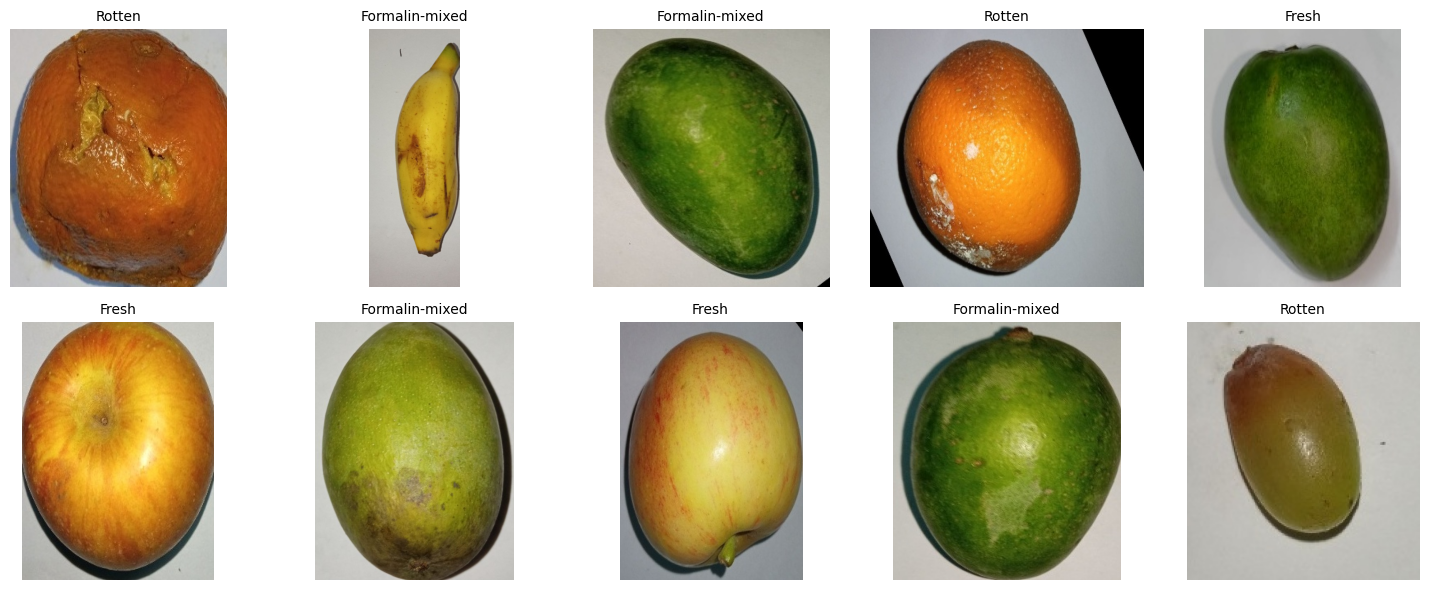

In [58]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

CROP_DIR = "/kaggle/working/fruit_crops"

files = os.listdir(CROP_DIR)
samples = random.sample(files, 10)

def infer_label(name):
    if "Fresh" in name:
        return "Fresh"
    elif "Rotten" in name:
        return "Rotten"
    elif "Formalin-mixed" in name:
        return "Formalin-mixed"
    else:
        return "Unknown"

fig, axes = plt.subplots(2, 5, figsize=(15,6))

for ax, fname in zip(axes.flatten(), samples):
    
    path = os.path.join(CROP_DIR, fname)
    img = Image.open(path)

    label = infer_label(fname)

    ax.imshow(img)
    ax.set_title(label, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()


# Final Regressor for output

In [60]:
ckpt = torch.load("/kaggle/working/simclr_latest.pth", map_location=device)

encoder.load_state_dict(ckpt["encoder"])
encoder.eval()                      # inference mode
for p in encoder.parameters():
    p.requires_grad = False         # freeze


### final dataset

In [69]:
class FruitQualityDataset(Dataset):
    def __init__(self, root):
        self.files = []
        self.fresh_labels = []
        self.is_formalin = []

        for fname in os.listdir(root):

            if not fname.endswith(".jpg"):
                continue

            lname = fname.lower()

            if "fresh" in lname:
                fresh_label = 1.0
                formalin_flag = 0

            elif "rotten" in lname:
                fresh_label = 0.0
                formalin_flag = 0

            elif "formalin" in lname:
                fresh_label = 0.0   # dummy (won’t be used)
                formalin_flag = 1

            else:
                continue

            self.files.append(os.path.join(root, fname))
            self.fresh_labels.append(fresh_label)
            self.is_formalin.append(formalin_flag)

        self.transform = transforms.Compose([
            transforms.Resize((128,128)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")
        img = self.transform(img)

        fresh_label = torch.tensor([self.fresh_labels[idx]], dtype=torch.float32)
        is_formalin = torch.tensor(self.is_formalin[idx], dtype=torch.bool)

        return img, fresh_label, is_formalin


# fRESH VS Rotten classifier
* as formalin doesnt mean it lies in between I am using one head to just classify rotten vs fresh
* other will be used for probability of being formalin mixed

In [70]:
class FreshnessRegressor(nn.Module):
    def __init__(self,emb_dim=256):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(emb_dim,64),
            nn.ReLU(),
            nn.Linear(64,16),
            nn.ReLU(),
            nn.Linear(16,1),
            nn.Sigmoid() # final output
        )

    def forward(self,x):
        return self.network(x)

In [71]:
class FormalinClassifier(nn.Module):
    def __init__(self, emb_dim=256):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(emb_dim,64),
            nn.ReLU(),
            nn.Linear(64,16),
            nn.ReLU(),
            nn.Linear(16,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.network(x)


In [72]:
FormalinClassifier()

FormalinClassifier(
  (network): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

In [73]:
FreshnessRegressor()

FreshnessRegressor(
  (network): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

### Loading data and train/val/test split

In [77]:
import os
import random
from collections import defaultdict

root = "/kaggle/working/fruit_crops"

groups = defaultdict(list)

# Group by fruit + class
for fname in os.listdir(root):
    if not fname.endswith(".jpg"):
        continue

    name = fname.lower()

    # detect class
    if "fresh" in name:
        cls = "fresh"
    elif "rotten" in name:
        cls = "rotten"
    elif "formalin" in name:
        cls = "formalin"
    else:
        continue

    # detect fruit (first word before _)
    fruit = fname.split("_")[0]

    key = f"{fruit}_{cls}"
    groups[key].append(fname)


train_files, val_files, test_files = [], [], []

for key, files in groups.items():

    random.shuffle(files)

    n = len(files)

    n_train = int(0.70 * n)
    n_val   = int(0.15 * n)

    train_files += files[:n_train]
    val_files   += files[n_train:n_train+n_val]
    test_files  += files[n_train+n_val:]


print("Train:", len(train_files))
print("Val:", len(val_files))
print("Test:", len(test_files))


Train: 31724
Val: 6793
Test: 6813


In [78]:
import shutil

base = "/kaggle/working"

train_dir = base + "/train_crops"
val_dir   = base + "/val_crops"
test_dir  = base + "/test_crops"

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

for f in train_files:
    shutil.copy(os.path.join(root, f), os.path.join(train_dir, f))

for f in val_files:
    shutil.copy(os.path.join(root, f), os.path.join(val_dir, f))

for f in test_files:
    shutil.copy(os.path.join(root, f), os.path.join(test_dir, f))
print("done")

done


In [80]:
train_dataset = FruitQualityDataset(train_dir)
val_dataset   = FruitQualityDataset(val_dir)
test_dataset  = FruitQualityDataset(test_dir)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)
print("done")

done


### Training loop

In [81]:
from tqdm import tqdm

regressor = FreshnessRegressor().to(device)
optimizer = torch.optim.Adam(regressor.parameters(), lr=1e-3)
loss_fn = nn.BCELoss()

encoder.eval()

train_loss_history = []
val_loss_history = []

epochs = 50   

for epoch in range(epochs):

    # -------- TRAIN --------
    regressor.train()
    total_train = 0
    train_count = 0

    for imgs, labels, is_formalin in tqdm(train_loader, desc=f"Train {epoch+1}/{epochs}"):

        imgs = imgs.to(device)
        labels = labels.to(device)
        is_formalin = is_formalin.to(device)

        mask = is_formalin == 0

        if mask.sum() == 0:
            continue

        imgs = imgs[mask]
        labels = labels[mask]

        with torch.no_grad():
            emb = encoder(imgs)

        preds = regressor(emb)

        loss = loss_fn(preds, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train += loss.item()
        train_count += 1

    avg_train_loss = total_train / train_count
    train_loss_history.append(avg_train_loss)


    # -------- VALIDATION --------
    regressor.eval()
    total_val = 0
    val_count = 0

    with torch.no_grad():

        for imgs, labels, is_formalin in val_loader:

            imgs = imgs.to(device)
            labels = labels.to(device)
            is_formalin = is_formalin.to(device)

            mask = is_formalin == 0

            if mask.sum() == 0:
                continue

            imgs = imgs[mask]
            labels = labels[mask]

            emb = encoder(imgs)
            preds = regressor(emb)

            loss = loss_fn(preds, labels)

            total_val += loss.item()
            val_count += 1

    avg_val_loss = total_val / val_count
    val_loss_history.append(avg_val_loss)


    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f}"
    )
        # ---- SAVE CHECKPOINT EVERY 5 EPOCHS ----
    if (epoch + 1) % 5 == 0:
        ckpt_path = f"/kaggle/working/freshnessmlp_epoch_{epoch+1}.pth"

        torch.save({
            "epoch": epoch + 1,
            "model_state": regressor.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "train_loss": train_loss_history,
            "val_loss": val_loss_history
        }, ckpt_path)

        print(f"Checkpoint saved: {ckpt_path}")



Train 1/50: 100%|██████████| 496/496 [01:15<00:00,  6.55it/s]


Epoch 1 | Train Loss: 0.4986 | Val Loss: 0.4035


Train 2/50: 100%|██████████| 496/496 [01:14<00:00,  6.61it/s]


Epoch 2 | Train Loss: 0.3680 | Val Loss: 0.3425


Train 3/50: 100%|██████████| 496/496 [01:15<00:00,  6.56it/s]


...

Epoch 48 | Train Loss: 0.1468 | Val Loss: 0.1578


Train 49/50: 100%|██████████| 496/496 [01:17<00:00,  6.39it/s]


Epoch 49 | Train Loss: 0.1466 | Val Loss: 0.1530


Train 50/50: 100%|██████████| 496/496 [01:17<00:00,  6.39it/s]


Epoch 50 | Train Loss: 0.1408 | Val Loss: 0.1660
Checkpoint saved: /kaggle/working/freshnessmlp_epoch_50.pth


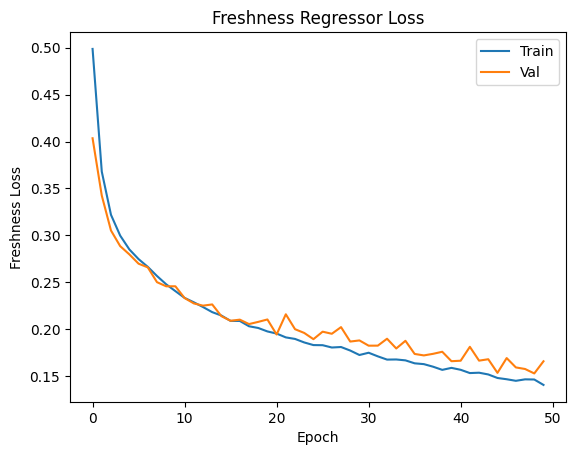

In [82]:
import matplotlib.pyplot as plt

plt.plot(train_loss_history, label="Train")
plt.plot(val_loss_history, label="Val")
plt.xlabel("Epoch")
plt.ylabel("Freshness Loss")
plt.legend()
plt.title("Freshness Regressor Loss")
plt.show()


Test Loss: 0.1682
Accuracy : 0.9307
Precision: 0.9074
Recall   : 0.9747
F1-score : 0.9399


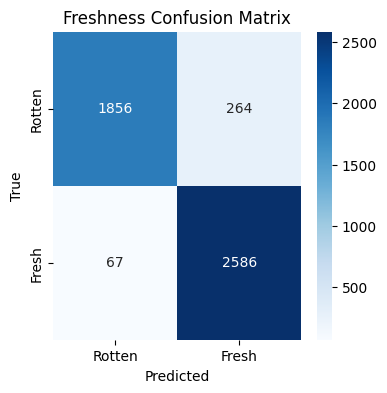

In [84]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

regressor.eval()
encoder.eval()

all_preds = []
all_labels = []
test_loss = 0
count = 0

with torch.no_grad():
    for imgs, labels, is_formalin in test_loader:

        imgs = imgs.to(device)
        labels = labels.to(device)
        is_formalin = is_formalin.to(device)

        # Only Fresh + Rotten
        mask = is_formalin == 0

        if mask.sum() == 0:
            continue

        imgs = imgs[mask]
        labels = labels[mask]

        emb = encoder(imgs)
        preds = regressor(emb)

        loss = loss_fn(preds, labels)

        test_loss += loss.item()
        count += 1

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


avg_test_loss = test_loss / count
print(f"Test Loss: {avg_test_loss:.4f}")


# ---- Convert probabilities to class ----
all_preds = np.array(all_preds).flatten()
all_labels = np.array(all_labels).flatten()

pred_classes = (all_preds >= 0.5).astype(int)   # threshold


# ---- Metrics ----
acc = accuracy_score(all_labels, pred_classes)
prec = precision_score(all_labels, pred_classes)
rec = recall_score(all_labels, pred_classes)
f1 = f1_score(all_labels, pred_classes)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")


# ---- Confusion Matrix ----
cm = confusion_matrix(all_labels, pred_classes)

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Rotten", "Fresh"],
            yticklabels=["Rotten", "Fresh"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Freshness Confusion Matrix")
plt.show()


# fORMALIN REGRESSOR

In [85]:
from tqdm import tqdm

formalin_head = FormalinClassifier().to(device)
optimizer_f = torch.optim.Adam(formalin_head.parameters(), lr=1e-3)
loss_fn_f = nn.BCELoss()

encoder.eval()

train_loss_f = []
val_loss_f = []

epochs = 40

for epoch in range(epochs):

    # ----- TRAIN -----
    formalin_head.train()
    total_train = 0
    count_train = 0

    for imgs, labels, is_formalin in tqdm(train_loader, desc=f"Train {epoch+1}/{epochs}"):

        imgs = imgs.to(device)
        is_formalin = is_formalin.float().to(device)

        with torch.no_grad():
            emb = encoder(imgs)

        preds = formalin_head(emb)

        loss = loss_fn_f(preds, is_formalin.unsqueeze(1))

        optimizer_f.zero_grad()
        loss.backward()
        optimizer_f.step()

        total_train += loss.item()
        count_train += 1

    avg_train_loss = total_train / count_train
    train_loss_f.append(avg_train_loss)


    # ----- VALIDATION -----
    formalin_head.eval()
    total_val = 0
    count_val = 0

    with torch.no_grad():

        for imgs, labels, is_formalin in val_loader:

            imgs = imgs.to(device)
            is_formalin = is_formalin.float().to(device)

            emb = encoder(imgs)
            preds = formalin_head(emb)

            loss = loss_fn_f(preds, is_formalin.unsqueeze(1))

            total_val += loss.item()
            count_val += 1

    avg_val_loss = total_val / count_val
    val_loss_f.append(avg_val_loss)


    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f}"
    )


    # ----- CHECKPOINT -----
    if (epoch+1) % 5 == 0:
        torch.save({
            "epoch": epoch+1,
            "model": formalin_head.state_dict(),
            "optimizer": optimizer_f.state_dict(),
            "train_loss": train_loss_f,
            "val_loss": val_loss_f
        }, f"/kaggle/working/formalinmlp_epoch_{epoch+1}.pth")


Train 1/40: 100%|██████████| 496/496 [01:18<00:00,  6.35it/s]


Epoch 1 | Train Loss: 0.5449 | Val Loss: 0.4890


Train 2/40: 100%|██████████| 496/496 [01:18<00:00,  6.31it/s]


Epoch 2 | Train Loss: 0.4609 | Val Loss: 0.4553


Train 3/40: 100%|██████████| 496/496 [01:19<00:00,  6.22it/s]


...

Epoch 38 | Train Loss: 0.2790 | Val Loss: 0.2868


Train 39/40: 100%|██████████| 496/496 [01:33<00:00,  5.28it/s]


Epoch 39 | Train Loss: 0.2799 | Val Loss: 0.2917


Train 40/40: 100%|██████████| 496/496 [01:32<00:00,  5.34it/s]


Epoch 40 | Train Loss: 0.2772 | Val Loss: 0.2846


### best checkpoint ig is : 

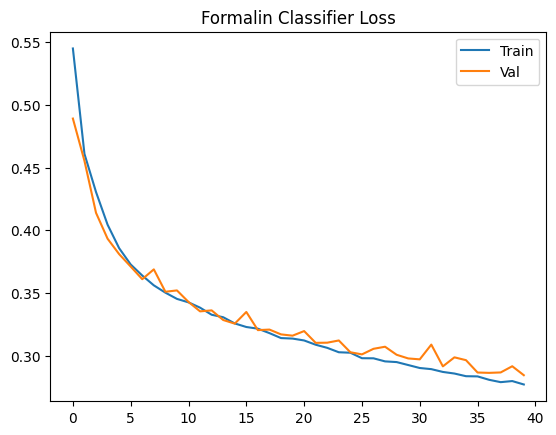

In [89]:
plt.plot(train_loss_f, label="Train")
plt.plot(val_loss_f, label="Val")
plt.legend()
plt.title("Formalin Classifier Loss")
plt.show()

Test Loss: 0.2782
Accuracy : 0.8702
Precision: 0.7504
Recall   : 0.8490
F1-score : 0.7967


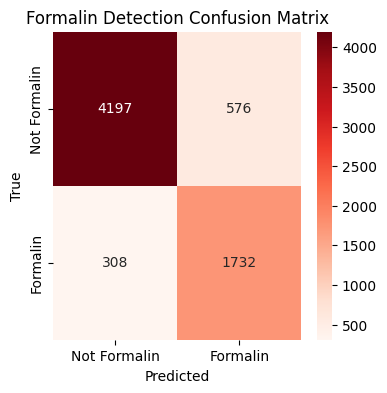

In [97]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

formalin_head.eval()
encoder.eval()

all_preds = []
all_labels = []
test_loss = 0
count = 0

with torch.no_grad():
    for imgs, labels, is_formalin in test_loader:

        imgs = imgs.to(device)
        is_formalin = is_formalin.float().to(device)

        emb = encoder(imgs)
        preds = formalin_head(emb)

        loss = loss_fn_f(preds, is_formalin.unsqueeze(1))

        test_loss += loss.item()
        count += 1

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(is_formalin.cpu().numpy())


avg_test_loss = test_loss / count
print(f"Test Loss: {avg_test_loss:.4f}")


# ---- Convert to binary class ----
all_preds = np.array(all_preds).flatten()
all_labels = np.array(all_labels).flatten()

pred_classes = (all_preds >= 0.4).astype(int)


# ---- Metrics ----
acc = accuracy_score(all_labels, pred_classes)
prec = precision_score(all_labels, pred_classes)
rec = recall_score(all_labels, pred_classes)
f1 = f1_score(all_labels, pred_classes)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")


# ---- Confusion Matrix ----
cm = confusion_matrix(all_labels, pred_classes)

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=["Not Formalin", "Formalin"],
            yticklabels=["Not Formalin", "Formalin"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Formalin Detection Confusion Matrix")
plt.show()


* 0.5
Test Loss: 0.2782
Accuracy : 0.8757
Precision: 0.8039
Recall   : 0.7735
F1-score : 0.7884

* 0.3
Test Loss: 0.2782
Accuracy : 0.8702
Precision: 0.7504
Recall   : 0.8490
F1-score : 0.7967

* 0.6
Test Loss: 0.2782
Accuracy : 0.8656
Precision: 0.8410
Recall   : 0.6794
F1-score : 0.7516


* 0.4
Test Loss: 0.2782
Accuracy : 0.8702
Precision: 0.7504
Recall   : 0.8490
F1-score : 0.7967


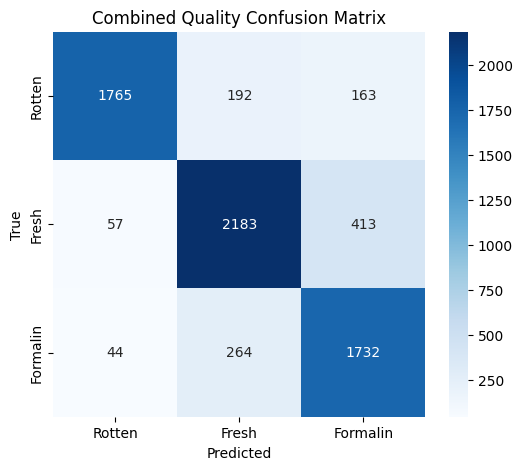

              precision    recall  f1-score   support

      Rotten       0.95      0.83      0.89      2120
       Fresh       0.83      0.82      0.83      2653
    Formalin       0.75      0.85      0.80      2040

    accuracy                           0.83      6813
   macro avg       0.84      0.83      0.84      6813
weighted avg       0.84      0.83      0.84      6813



In [98]:
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

THRESH_FORMALIN = 0.4   
THRESH_FRESH = 0.5

encoder.eval()
regressor.eval()
formalin_head.eval()

true_classes = []
pred_classes = []

# Class encoding:
# 0 = Rotten
# 1 = Fresh
# 2 = Formalin

with torch.no_grad():

    for imgs, labels, is_formalin in test_loader:

        imgs = imgs.to(device)
        labels = labels.to(device)
        is_formalin = is_formalin.to(device)

        emb = encoder(imgs)

        fresh_preds = regressor(emb).squeeze()
        formalin_preds = formalin_head(emb).squeeze()

        for i in range(len(imgs)):

            # ---- TRUE LABEL ----
            if is_formalin[i] == 1:
                true_cls = 2   # Formalin
            else:
                true_cls = 1 if labels[i] >= 0.5 else 0

            # ---- PREDICTED LABEL ----
            if formalin_preds[i] >= THRESH_FORMALIN:
                pred_cls = 2   # Formalin
            else:
                pred_cls = 1 if fresh_preds[i] >= THRESH_FRESH else 0

            true_classes.append(true_cls)
            pred_classes.append(pred_cls)


true_classes = np.array(true_classes)
pred_classes = np.array(pred_classes)


# ---- CONFUSION MATRIX ----
cm = confusion_matrix(true_classes, pred_classes)

labels = ["Rotten", "Fresh", "Formalin"]

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Combined Quality Confusion Matrix")
plt.show()


# ---- CLASSIFICATION REPORT ----
print(classification_report(
    true_classes,
    pred_classes,
    target_names=labels
))
